In [253]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad

- Номер примера 14 
- (III) тип граничных условий

$$
S'(a) = S'(b) \quad
S''(a) = S''(b)
$$

In [254]:
def f(x): 
    return np.sin(x ** 2 / 4)

In [255]:
def build_periodic_spline_moments(x, y, eps):
    n = len(x) - 1
    h = x[1] - x[0]
    
    A = np.zeros((n, n))
    d = np.zeros(n)
    
    for i in range(1, n):
        A[i, i-1] = (1 - (eps ** 2) / (h ** 2)) / 2  # μ_i
        A[i, i] = 2 + (eps ** 2) / (h ** 2)
        A[i, (i+1) % n] = (1 - (eps ** 2) / (h ** 2)) / 2  # λ_i
        d[i] = 3 * (y[i + 1] - 2 * y[i] + y[i - 1]) / (h ** 2)
    
    # Уравнение для узла i=0 с учетом периодичности
    A[0, 0] = 2 + (eps ** 2) / (h ** 2)
    A[0, 1] = (1 - (eps ** 2) / (h ** 2)) / 2  # λ_0
    A[0, n-1] = (1 - (eps ** 2) / (h ** 2)) / 2  # μ_0 (связь с последним узлом m_{n-1})
    d[0] = 3 * (y[1] - 2 * y[0] + y[n-1]) / (h ** 2)  # y_{-1} = y_{n-1}
    
    # Уравнение для узла i=n-1 с учетом периодичности  
    A[n-1, n-1] = -1
    A[n-1, 0] = 1
    d[n-1] = 0
    
    m = np.linalg.solve(A, d)
    m = np.append(m, m[0])
    
    return m, h

In [256]:
def periodic_spline_eval(x, y, M, h, x_eval):
    n = len(x) - 1
    y_eval = np.zeros_like(x_eval)
    
    for i, x_val in enumerate(x_eval):
        idx = np.searchsorted(x, x_val) - 1
        idx = max(0, min(idx, n-1))

        t = (x_val - x[idx]) / h

        y_eval[i] = (
            y[idx] * (1 - t) + t * y[idx + 1] - 
            t * (1 - t) * (h ** 2) * ((2 - t) * M[idx] + (1 + t) * M[idx + 1]) / 6
        )
    
    return y_eval

5.300655118075871e-07


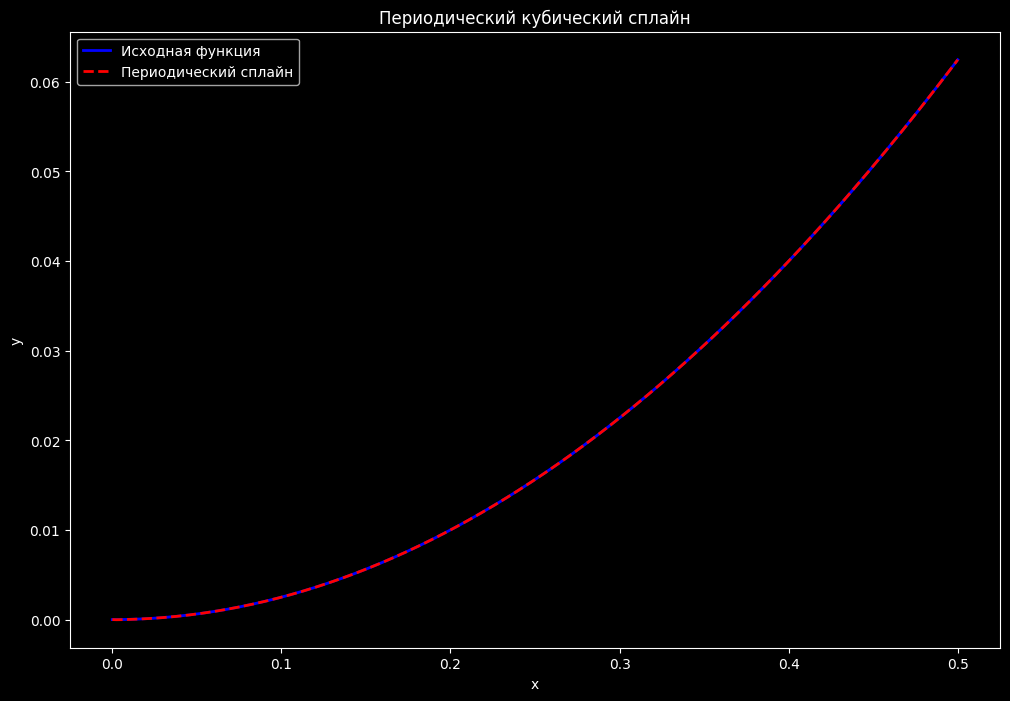

In [257]:
a, b = 0, 0.5
N = 200

x = np.linspace(a, b, N + 1)
y = f(x)

# Построение сплайна
M, h = build_periodic_spline_moments(x, y, eps=0.01)

# Вычисление на плотной сетке
x_dense = np.linspace(a, b, 200)
y_dense = f(x_dense)
y_spline = periodic_spline_eval(x, y, M, h, x_dense)

print(np.mean(np.abs(y_spline - y_dense)))

plt.figure(figsize=(12, 8))
plt.plot(x_dense, y_dense, 'blue', label='Исходная функция', linewidth=2)
plt.plot(x_dense, y_spline, 'red', linestyle='--', label='Периодический сплайн', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Периодический кубический сплайн')
plt.legend()

plt.show()

In [258]:
def integrate(M, y, h):
    result = 0
    for i in range(0, len(y)-1):
        result += (
            (y[i] + y[i + 1]) / 2 -
            (h ** 2) * (M[i] + M[i + 1]) / 24
        )

    return result * h

In [259]:
I = 0.0104139716929

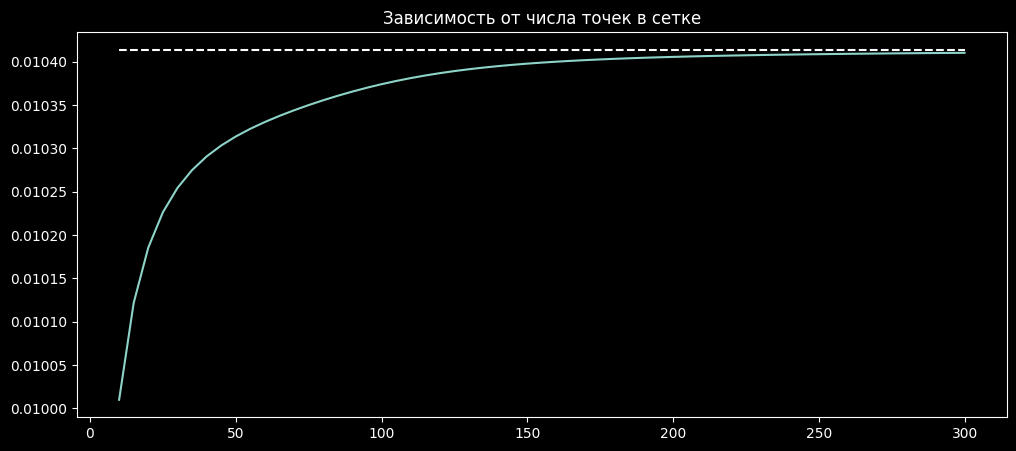

In [260]:
N_vals = list(range(10, 301, 5))
I_vals = []

for N in N_vals: 
    a, b = 0, 0.5

    x = np.linspace(a, b, N + 1)
    y = f(x)

    M, h = build_periodic_spline_moments(x, y, eps=0.01)

    I_vals.append(integrate(M, y, h))

plt.figure(figsize=(12, 5))

plt.plot(N_vals, I_vals)
plt.hlines([I], xmin=N_vals[0], xmax=N_vals[-1], linestyles='--', colors='white')

plt.title('Зависимость от числа точек в сетке')

plt.show()

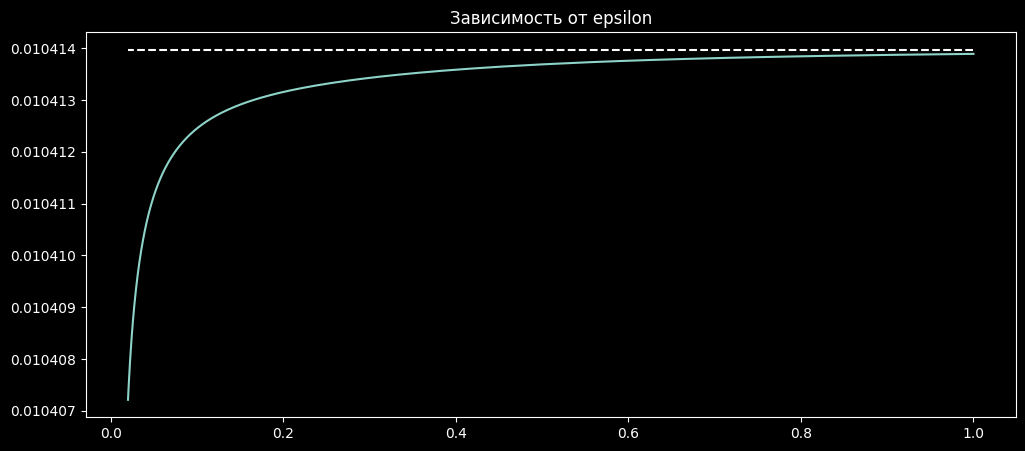

In [261]:
eps_vals = []
I_vals = []

for d in np.arange(1, 50, 0.1): 
    a, b = 0, 0.5
    N = 150

    eps = 1 / d
    eps_vals.append(eps)

    x = np.linspace(a, b, N + 1)
    y = f(x)

    M, h = build_periodic_spline_moments(x, y, eps=eps)

    I_vals.append(integrate(M, y, h))

plt.figure(figsize=(12, 5))

plt.plot(eps_vals, I_vals)
plt.hlines([I], xmin=eps_vals[0], xmax=eps_vals[-1], linestyles='--', colors='white')

plt.title('Зависимость от epsilon')

plt.show()